# Swap-less implementation of the QFT

This notebook demonstrates the swap-less compilation of the QFT using temporal parity computing and the extended LHZ architecture. The QFT is a landmark quantum algorthm and is defined as:

$$U_{\mathrm{QFT}} = \prod_{i=1}^{n} \left[ H_i \prod_{j=i+1}^{n} \mathrm{CP}_{ij} \left( \frac{\pi}{2^{j-i}} \right) \right].$$

where the controlled-phase gate is defined as $\mathrm{CP}_{jk} (\theta) = \mathrm{diag}(1,1,1,e^{i\theta}).$ To express the QFT in a form compatible with parity-label compilation, the controlled-phase gates are first decomposed into logical $Z$-parity rotations using:
$$\overline{\mathrm{CP}}_{ij}(\theta) = R_{\mathrm{Z}}^{(i)}\left( \frac{\theta}{2} \right) R_{\mathrm{Z}}^{(ij)}\left( -\frac{\theta}{2} \right) R_{\mathrm{Z}}^{(j)}\left( \frac{\theta}{2} \right), $$
where $R_{\mathrm{Z}}^{(ij)}$ denotes a logical parity rotation generated by $\bar{Z}_i\bar{Z}_j$. Similarly, the Hadamard gates can be decomposed as
$$    \bar{H}_{i} = \bar{R}_{\mathrm{Z}}^{(i)}\left( \frac{\pi}{2} \right) \bar{R}_{\mathrm{X}}^{(i)}\left( \frac{\pi}{2} \right) \bar{R}_{\mathrm{Z}}^{(i)}\left( \frac{\pi}{2} \right). $$

The goal is to start from the standard QFT circuit, rewrite it in terms of logical parity rotations, generate the corresponding sequence of LHZ spanning lines, and finally compile the circuit into local single-qubit rotations and nearest-neighbour CNOT gates. The notebook first illustrates the full procedure for a small system with \(n=5\) qubits, where the resulting circuit can be inspected visually, and then repeats the same compilation pipeline for a larger \(n=52\) QFT circuit.

The main functions used in the notebook are:

- `generate_standard_qft_gates`: generates the standard QFT circuit as a list of Hadamard and controlled-phase gates.

- `decompose_h_cphase_to_rx_rz`: rewrites the QFT gates in terms of logical \(R_Z\), parity-\(R_Z\), and \(R_X\) rotations, which are the operations used by the parity-label compiler.

- `compress_rx_rz_operations`: simplifies the logical operation list by commuting compatible \(R_Z\) rotations and combining rotations acting on the same logical support.

- `generate_lhz_spanning_lines_left_to_right`: constructs the sequence of LHZ spanning lines used to implement the QFT. These lines describe how the parity labels assigned to the physical qubits evolve during the temporal parity computation.

- `compile_qft_with_lhz_spanning_lines`: compiles the logical QFT operations into a physical circuit. It inserts the CNOT gates required to move between spanning lines and replaces each logical operation by the corresponding local physical operation.

- `draw_compiled_ops_pennylane`: draws the compiled circuit using PennyLane, allowing the final swap-less implementation to be visualized.

The output of the compiler is compared against the theoretical resource estimates for the swap-less QFT construction, including the CNOT count, single-qubit rotation count, total gate count, CNOT depth, single-qubit depth, and total depth.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Scripts.QFT_gates import (
    generate_standard_qft_gates,
    decompose_h_cphase_to_rx_rz,
    compress_rx_rz_operations,
)
from Scripts.QFT_spanning_lines import generate_lhz_spanning_lines_left_to_right
from Scripts.QFT_compiler import compile_qft_with_lhz_spanning_lines
from Scripts.Circuit_plotter import draw_compiled_ops_pennylane

In [2]:
n = 5

qft_gates = generate_standard_qft_gates(n)
rx_rz_gates = decompose_h_cphase_to_rx_rz(qft_gates)

compressed_gates = compress_rx_rz_operations(rx_rz_gates)

spanning_data = generate_lhz_spanning_lines_left_to_right(
    n,
    return_cnot_steps=True,
    verbose=False,
)

compiled_ops, debug = compile_qft_with_lhz_spanning_lines(
    compressed_gates,
    n,
    spanning_data=spanning_data,
    return_debug=True,
    verbose=False,
)

print("CNOT count:", debug["cnot_count"], " \n Theoretical CNOT count:", int(n**2 - 1))
print("Single qubit rotations:", debug['rotation_count'], "\n Theoretical Single qubit count:", int(0.5*n**2 +2.5*n - 2))
print("Total gates:", debug['rotation_count'] + debug["cnot_count"])
print("Expected total gate:", int(1.5*n**2 + 2.5*n -3))
print('---------------------------------')
print("CNOT depth:", debug["cnot_depth"], " \n Theoretical CNOT depth:", int(4*n - 4))
print("Single qubit depth:", debug["single_qubit_depth"], " \n Theoretical single qubit depth:", int(2*n - 1))
print("Total depth:", debug["single_qubit_depth"] + debug["cnot_depth"], " \n Theoretical total depth:", int(6*n - 5))


CNOT count: 24  
 Theoretical CNOT count: 24
Single qubit rotations: 23 
 Theoretical Single qubit count: 23
Total gates: 47
Expected total gate: 47
---------------------------------
CNOT depth: 16  
 Theoretical CNOT depth: 16
Single qubit depth: 9  
 Theoretical single qubit depth: 9
Total depth: 25  
 Theoretical total depth: 25


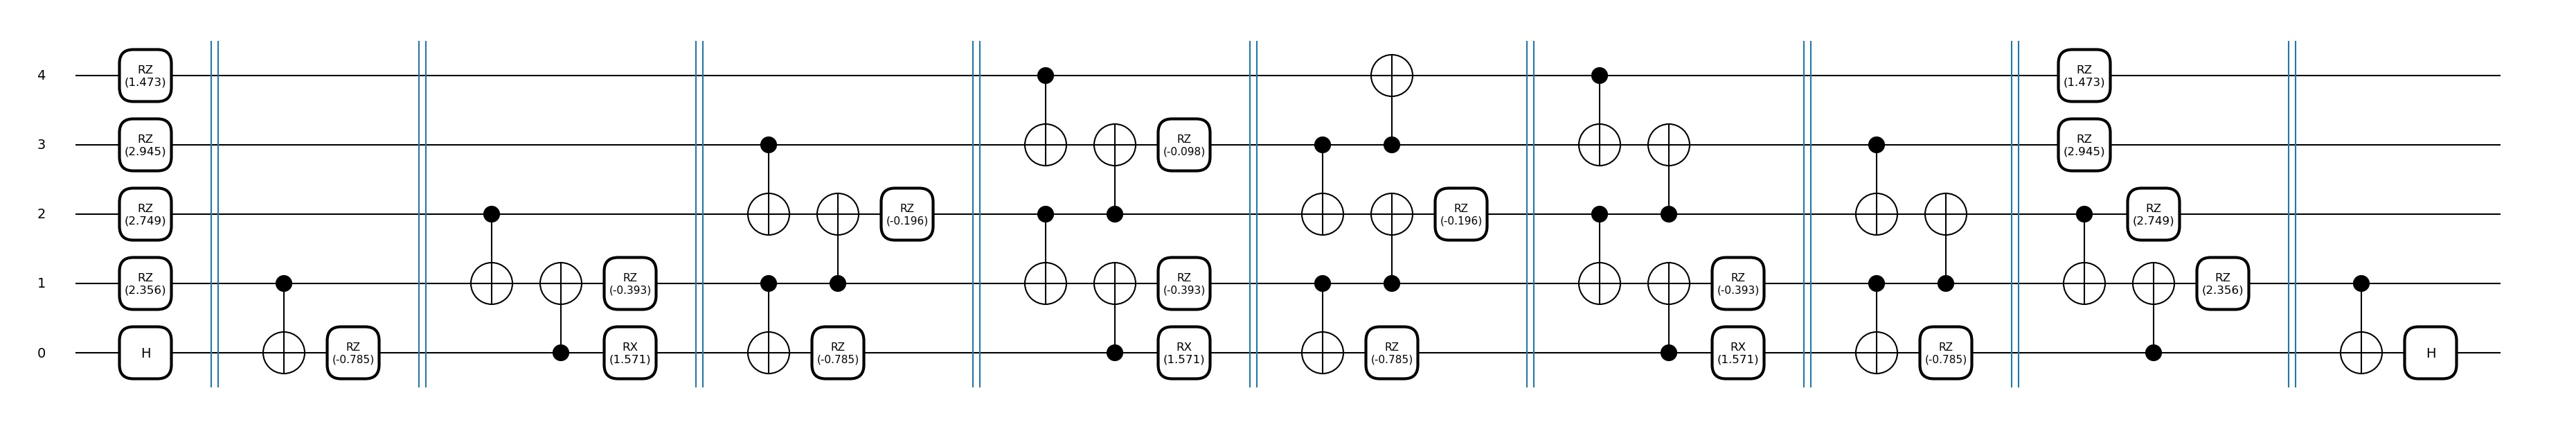

In [3]:
fig, ax = draw_compiled_ops_pennylane(compiled_ops, debug, n_wires=n)

### Finally I will now plot the circuit for a 52 qubit QFT, the world record dimension for a QFT on quantum hardware which is currently held by ParityQC.  

In [4]:
n = 52

qft_gates = generate_standard_qft_gates(n)
rx_rz_gates = decompose_h_cphase_to_rx_rz(qft_gates)

compressed_gates = compress_rx_rz_operations(rx_rz_gates)

spanning_data = generate_lhz_spanning_lines_left_to_right(
    n,
    return_cnot_steps=True,
    verbose=False,
)

compiled_ops, debug = compile_qft_with_lhz_spanning_lines(
    compressed_gates,
    n,
    spanning_data=spanning_data,
    return_debug=True,
    verbose=False,
)

print("CNOT count:", debug["cnot_count"], " \n Theoretical CNOT count:", int(n**2 - 1))
print("Single qubit rotations:", debug['rotation_count'], "\n Theoretical Single qubit count:", int(0.5*n**2 +2.5*n - 2))
print("Total gates:", debug['rotation_count'] + debug["cnot_count"])
print("Expected total gate:", int(1.5*n**2 + 2.5*n -3))
print('---------------------------------')
print("CNOT depth:", debug["cnot_depth"], " \n Theoretical CNOT depth:", int(4*n - 4))
print("Single qubit depth:", debug["single_qubit_depth"], " \n Theoretical single qubit depth:", int(2*n - 1))
print("Total depth:", debug["single_qubit_depth"] + debug["cnot_depth"], " \n Theoretical total depth:", int(6*n - 5))

CNOT count: 2703  
 Theoretical CNOT count: 2703
Single qubit rotations: 1480 
 Theoretical Single qubit count: 1480
Total gates: 4183
Expected total gate: 4183
---------------------------------
CNOT depth: 204  
 Theoretical CNOT depth: 204
Single qubit depth: 103  
 Theoretical single qubit depth: 103
Total depth: 307  
 Theoretical total depth: 307


In [5]:
fig, ax = draw_compiled_ops_pennylane(compiled_ops, debug, n_wires=n)